<a href="https://colab.research.google.com/github/FONDECYTACC/cons2025/blob/main/Deep_Hit_jan26.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## 0. Package loading and installation



In [25]:
# Commented out IPython magic to ensure Python compatibility.
# For Jupyter/Colab notebooks
# %reset -f
import gc
gc.collect()

import numpy as np
import pandas as pd
import time

!pip install scikit-survival --upgrade -q
!pip install lifelines -q
!pip install torchtuples -q

import sys
import subprocess

!pip install pycox torchtuples
!pip install scikit-survival

try:
    from survlimepy import SurvLimeExplainer
except ImportError:
    !pip install survlimepy
    from survlimepy import SurvLimeExplainer

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

# Check device
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"✅ Compute Device: {device}")

from sksurv.metrics import (
    concordance_index_ipcw,
    brier_score,
    integrated_brier_score
)
from sksurv.util import Surv



#Glimpse function
def glimpse(df, max_width=80):
    print(f"Rows: {df.shape[0]} | Columns: {df.shape[1]}")
    for col in df.columns:
        dtype = df[col].dtype
        preview = df[col].astype(str).head(5).tolist()
        preview_str = ", ".join(preview)
        if len(preview_str) > max_width:
            preview_str = preview_str[:max_width] + "..."
        print(f"{col:<30} {str(dtype):<15} {preview_str}")
#Tabyl function
def tabyl(series):
    counts = series.value_counts(dropna=False)
    props = series.value_counts(normalize=True, dropna=False)
    return pd.DataFrame({"value": counts.index,
                         "n": counts.values,
                         "percent": props.values})
#clean_names
import re

def clean_names(df):
    """
    Mimic janitor::clean_names for pandas DataFrames.
    - Lowercase
    - Replace spaces and special chars with underscores
    - Remove non-alphanumeric/underscore
    """
    new_cols = []
    for col in df.columns:
        # lowercase
        col = col.lower()
        # replace spaces and special chars with underscore
        col = re.sub(r"[^\w]+", "_", col)
        # strip leading/trailing underscores
        col = col.strip("_")
        new_cols.append(col)
    df.columns = new_cols
    return df


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 48.1/48.1 kB 2.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 4.1 MB/s eta 0:00:00
  Installing build dependencies ... done
  error: subprocess-exited-with-error
  
  × Getting requirements to build wheel did not run successfully.
  │ exit code: 1
  ╰─> See above for output.
  
  note: This error originates from a subprocess, and is likely not a problem with pip.
  Getting requirements to build wheel ... error
error: subprocess-exited-with-error

× Getting requirements to build wheel did not run successfully.
│ exit code: 1
╰─> See above for output.

note: This error originates from a subprocess, and is likely not a problem with pip.


ModuleNotFoundError: No module named 'survlimepy'

Load data

In [14]:
from google.colab import userdata

# Names of the objects (and secrets)
object_names = [
    "imputations_list_jan26",
    "imputation_nodum_1",
    "X_reduced_imp0",
    "imputation_1"
]
for name in object_names:
    file_id = userdata.get(name)   # secret stored with this key
    if file_id is None:
        raise ValueError(f"No file_id found in userdata for key '{name}'")

    output_file = f"{name}.pkl"
    print(f"Downloading {name} -> {output_file}")
    !gdown {file_id} --output {output_file} --quiet


Load in python

In [15]:

import pandas as pd

# Example: load only imputation 1
imputation_nodum_1 = pd.read_parquet("/content/imputation_nodum_1.pkl")
X_reduced_imp0 = pd.read_parquet("/content/X_reduced_imp0.pkl")
imputation_1 = pd.read_parquet("/content/imputation_1.pkl")

# Quick check
glimpse(imputation_nodum_1)
glimpse(imputation_1)
glimpse(X_reduced_imp0)

import pickle
import pandas as pd
import numpy as np

file_path = '/content/imputations_list_jan26.pkl'

with open(file_path, 'rb') as f:
    imputations_list_jan26 = pickle.load(f)

print(f"Successfully loaded '{file_path}'\n")
print(f"Type of loaded object: {type(imputations_list_jan26)}")

if isinstance(imputations_list_jan26, list) and len(imputations_list_jan26) > 0:
    print("First element type:", type(imputations_list_jan26[0]))
    if isinstance(imputations_list_jan26[0], dict):
        print("First element keys:", imputations_list_jan26[0].keys())
    elif isinstance(imputations_list_jan26[0], (pd.DataFrame, np.ndarray)):
        print("First element shape:", imputations_list_jan26[0].shape)

Rows: 88504 | Columns: 41
readmit_time_from_adm_m        float64         84.93548387096774, 12.833333333333334, 13.733333333333333, 11.966666666666667, 1...
death_time_from_adm_m          float64         84.93548387096774, 87.16129032258064, 117.2258064516129, 98.93548387096774, 37.9...
adm_age_rec3                   float64         31.53, 20.61, 42.52, 60.61, 45.08
porc_pobr                      float64         0.175679117441177, 0.187835901975632, 0.130412444472313, 0.133759185671806, 0.08...
dit_m                          float64         15.967741935483872, 5.833333333333334, 0.4752688172043005, 6.966666666666667, 6....
sex_rec                        category        man, man, man, woman, man
tenure_status_household        category        stays temporarily with a relative, owner/transferred dwellings/pays dividends, s...
cohabitation                   category        alone, family of origin, with couple/children, with couple/children, family of o...
sub_dep_icd10_status           cat

This code block:

1.  **Imports the `pickle` library**: This library implements binary protocols for serializing and de-serializing a Python object structure.
2.  **Specifies the `file_path`**: It points to the `.pkl` file you selected.
3.  **Opens the file in binary read mode (`'rb'`)**: This is necessary for loading pickle files.
4.  **Loads the object**: `pickle.load(f)` reads the serialized object from the file and reconstructs it in memory.
5.  **Prints confirmation and basic information**: It verifies that the file was loaded and shows the type of the loaded object, and some details about the first element if it's a list containing common data structures.



#### Compare databases (transformed and original)

Inspect and compare the column names of two datasets: the first imputation from imputations_list_jan26 (which likely contains dummy variables) and imputation_nodum_1 (which, as its name suggests, probably doesn't have dummy variables).

In [16]:
# Inspect columns of the first imputation
cols_first_imp = imputations_list_jan26[0].columns.tolist()
print("First imputation columns:", cols_first_imp[:10], "... total:", len(cols_first_imp))

# Inspect columns of imputation_no_dum
cols_nodum = imputation_nodum_1.columns.tolist()
print("No-dum columns:", cols_nodum[:10], "... total:", len(cols_nodum))

# Compare overlap
common_cols = set(cols_first_imp).intersection(cols_nodum)
missing_in_imp = [c for c in cols_nodum if c not in cols_first_imp]
missing_in_nodum = [c for c in cols_first_imp if c not in cols_nodum]

print("Common columns:", len(common_cols))
print("Missing in imputations_list_jan26:", missing_in_imp)

# Inspect columns of the first imputation
cols_first_imp_raw = imputation_1.columns.tolist()
print("First imputation columns:", cols_first_imp_raw[:10], "... total:", len(cols_first_imp_raw))

# Compare overlap
common_cols_raw = set(cols_first_imp_raw).intersection(cols_nodum)
missing_in_imp_raw = [c for c in cols_nodum if c not in cols_first_imp_raw]

print("Common columns:", len(common_cols_raw))
print("Missing in imputations_list_jan26:", missing_in_imp_raw)
print(common_cols_raw)

import pandas as pd

# Example: choose a combination of variables that uniquely identify rows
key_vars = ["adm_age_rec3", "porc_pobr", "dit_m"]

# Take one imputation (first element of the list) and merge with the no-dum dataset
df_imp = imputations_list_jan26[0]
df_nodum = imputation_nodum_1

merged_check = pd.merge(
    df_imp[key_vars],
    df_nodum[key_vars],
    on=key_vars,
    how="inner"
)

print(f"Merged rows: {merged_check.shape[0]}")
print("Preview of merged check:")
print(merged_check.head())

#drop merge
del merged_check

import pandas as pd

# Example: choose a combination of variables that uniquely identify rows
key_vars_raw = ['dit_m',
            'readmit_time_from_adm_m',
            'death_time_from_adm_m',
            'adm_age_rec3']
# Take one imputation (first element of the list) and merge with the no-dum dataset
df_raw = imputation_1

merged_check_raw = pd.merge(
    df_imp[key_vars],
    df_raw[key_vars],
    on=key_vars,
    how="inner"
)

print(f"Merged rows: {merged_check_raw.shape[0]}")
print("Preview of merged check:")
print(merged_check_raw.head())
print(f"{(merged_check_raw.shape[0] / imputation_1.shape[0] * 100):.2f}%")
#drop merge
del merged_check_raw


First imputation columns: ['adm_age_rec3', 'porc_pobr', 'dit_m', 'tenure_status_household', 'prim_sub_freq_rec', 'national_foreign', 'urbanicity_cat', 'ed_attainment_corr', 'evaluacindelprocesoteraputico', 'eva_consumo'] ... total: 56
No-dum columns: ['readmit_time_from_adm_m', 'death_time_from_adm_m', 'adm_age_rec3', 'porc_pobr', 'dit_m', 'sex_rec', 'tenure_status_household', 'cohabitation', 'sub_dep_icd10_status', 'any_violence'] ... total: 41
Common columns: 24
Missing in imputations_list_jan26: ['readmit_time_from_adm_m', 'death_time_from_adm_m', 'sex_rec', 'cohabitation', 'sub_dep_icd10_status', 'any_violence', 'tr_outcome', 'adm_motive', 'first_sub_used', 'primary_sub_mod', 'tipo_de_vivienda_rec2', 'plan_type_corr', 'occupation_condition_corr24', 'marital_status_rec', 'readmit_event', 'death_event', 'center_id']
First imputation columns: ['readmit_time_from_adm_m', 'death_time_from_adm_m', 'adm_age_rec3', 'porc_pobr', 'dit_m', 'national_foreign', 'ethnicity', 'dg_psiq_cie_10_inst

### Create bins for followup (landmarks)

This code prepares your data for survival analysis. It extracts the time until an event (like readmission or death) and whether that event actually happened for each patient from the df_nodum dataset. Then, it automatically creates a set of important time points, called an 'evaluation grid', which are specific moments to assess the model's performance on both readmission and death outcomes.


In [17]:
import numpy as np

# Required columns for survival outcomes
required = ["readmit_time_from_disch_m", "readmit_event",
            "death_time_from_disch_m", "death_event"]

# Check that df_raw has all required columns
missing = [c for c in required if c not in df_raw.columns]
if missing:
    raise KeyError(f"df_nodum is missing columns: {missing}")

# Create time/event arrays directly from df_raw
time_readm = df_raw["readmit_time_from_adm_m"].to_numpy()
event_readm = (df_raw["readmit_event"].to_numpy() == 1)

time_death = df_raw["death_time_from_adm_m"].to_numpy()
event_death = (df_nodum["death_event"].to_numpy() == 1)

print("Arrays created for df_raw:")
print("Readmission times:", time_readm[:5])
print("Readmission events:", event_readm[:5])
print("Death times:", time_death[:5])
print("Death events:", event_death[:5])

# Build evaluation grids (quantiles of event times)
event_times_readm = time_readm[event_readm]
event_times_death = time_death[event_death]

if len(event_times_readm) < 5 or len(event_times_death) < 5:
    raise ValueError("Too few events in df_raw to build reliable time grids.")

times_eval_readm = np.unique(np.quantile(event_times_readm, np.linspace(0.05, 0.95, 50)))
times_eval_death = np.unique(np.quantile(event_times_death, np.linspace(0.05, 0.95, 50)))

print("Eval times (readmission):", times_eval_readm[:5], "...", times_eval_readm[-5:])
print("Eval times (death):", times_eval_death[:5], "...", times_eval_death[-5:])


Arrays created for df_raw:
Readmission times: [84.93548387 12.83333333 13.73333333 11.96666667 14.25806452]
Readmission events: [False  True  True  True  True]
Death times: [ 84.93548387  87.16129032 117.22580645  98.93548387  37.93548387]
Death events: [False False False False False]
Eval times (readmission): [3.93548387 4.77419355 5.45058701 6.06492649 6.67741935] ... [54.44173469 58.41566162 63.23333333 68.54767171 74.68983871]
Eval times (death): [4.16290323 5.43022383 6.68564845 8.24254115 9.77961817] ... [81.92700461 85.41186103 88.78518762 93.5538183  99.21935484]


Prepare survival data



In [18]:
import numpy as np

# Step 1. Extract survival outcomes directly from df_raw
time_readm = df_raw["readmit_time_from_adm_m"].to_numpy()
event_readm = (df_raw["readmit_event"].to_numpy() == 1)

time_death = df_raw["death_time_from_adm_m"].to_numpy()
event_death = (df_raw["death_event"].to_numpy() == 1)

# Step 2. Build structured arrays (Surv objects)
y_surv_readm = np.empty(len(time_readm), dtype=[("event", "?"), ("time", "<f8")])
y_surv_readm["event"] = event_readm
y_surv_readm["time"] = time_readm

y_surv_death = np.empty(len(time_death), dtype=[("event", "?"), ("time", "<f8")])
y_surv_death["event"] = event_death
y_surv_death["time"] = time_death

# Step 3. Replicate across imputations
n_imputations = len(imputations_list_jan26)
y_surv_readm_list = [y_surv_readm for _ in range(n_imputations)]
y_surv_death_list = [y_surv_death for _ in range(n_imputations)]

## PyCox

In [38]:
#@title ⚡ DeepHit Analysis (Fixed Types & Shapes) { display-mode: "form" }

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torchtuples as tt
from pycox.models import DeepHit
from pycox.preprocessing.label_transforms import LabTransDiscreteTime
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, f1_score, roc_curve
from sksurv.metrics import concordance_index_censored

# --- SAFETY CHECK ---
try:
    len(imputations_list_jan26)
except NameError:
    raise NameError("❌ Data not found. Please reload 'imputations_list_jan26' first.")

# --- CONFIGURATION ---
N_IMPUTATIONS = len(imputations_list_jan26)
K_FOLDS = 10 #5
TIMES_EVAL = [12, 24, 36, 48, 60, 72, 84, 96]
NUM_DURATIONS = 100 #50
BATCH_SIZE = 512 #256
EPOCHS = 200
LR = 0.01

# CRITICAL FIX 1: Set Risks to 3 (0=Censored, 1=Death, 2=Readm)
# This prevents "Index Out of Bounds" when the loss function indexes the output layer.
NUM_RISKS = 3

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"⚡ Starting DeepHit Analysis on: {device.upper()}")
print("-" * 60)

# --- HELPER FUNCTIONS ---
def get_binary_target(events, times, risk_id, t_horizon):
    is_case = (events == risk_id) & (times <= t_horizon)
    is_control = (times > t_horizon) | ((events != risk_id) & (events != 0) & (times <= t_horizon))
    valid_mask = is_case | is_control
    return is_case[valid_mask].astype(int), valid_mask

def calc_metrics(y_true, probas):
    if len(np.unique(y_true)) < 2: return {}
    fpr, tpr, thresholds = roc_curve(y_true, probas)
    idx = np.argmax(tpr - fpr)
    thresh = thresholds[idx]
    y_pred = (probas >= thresh).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0,1]).ravel()
    with np.errstate(divide='ignore'):
        return {
            'F1': f1_score(y_true, y_pred),
            'Sens': tp/(tp+fn) if (tp+fn)>0 else 0,
            'Spec': tn/(tn+fp) if (tn+fp)>0 else 0
        }

# CRITICAL FIX 2: Wrapper to reshape Network Output
# Standard MLPVanilla outputs 2D (Batch, Features).
# DeepHit Loss expects 3D (Batch, Risks, Durations).
class CauseSpecificNet(nn.Module):
    def __init__(self, net, num_risks):
        super().__init__()
        self.net = net
        self.num_risks = num_risks

    def forward(self, x):
        out = self.net(x)
        # Reshape to (Batch, Risks, Durations)
        return out.view(out.size(0), self.num_risks, -1)

# --- MAIN PIPELINE ---
results_log = []

for imp_idx in range(N_IMPUTATIONS):
    # 1. LOAD DATA
    X_raw = imputations_list_jan26[imp_idx]
    X_curr = pd.get_dummies(X_raw, drop_first=True).astype('float32')

    y_d = y_surv_death_list[imp_idx]
    y_r = y_surv_readm_list[imp_idx]

    # Robust array extraction
    if hasattr(y_d['time'], 'values'):
        t_base = y_d['time'].values.astype('float32')
        e_d = y_d['event'].values.astype(bool)
        e_r = y_r['event'].values.astype(bool)
    else:
        t_base = y_d['time'].astype('float32')
        e_d = y_d['event'].astype(bool)
        e_r = y_r['event'].astype(bool)

    # 2. BUILD COMPETING RISKS TARGET
    events_cr = np.zeros_like(t_base, dtype=int)
    mask_both = e_d & e_r

    t_r_vals = y_r['time'].values if hasattr(y_r['time'], 'values') else y_r['time']

    # Priority logic
    events_cr[mask_both & (t_base <= t_r_vals)] = 1
    events_cr[mask_both & (t_r_vals < t_base)] = 2
    events_cr[e_d & (~e_r)] = 1
    events_cr[e_r & (~e_d)] = 2

    times_cr = t_base.copy()

    print(f"\n📂 Processing Imputation {imp_idx + 1}/{N_IMPUTATIONS}...", end="")

    # 3. CROSS-VALIDATION
    skf = StratifiedKFold(n_splits=K_FOLDS, shuffle=True, random_state=2125)

    for fold_idx, (train_idx, val_idx) in enumerate(skf.split(X_curr, events_cr)):

        X_train, X_val = X_curr.iloc[train_idx].values, X_curr.iloc[val_idx].values
        t_train, e_train = times_cr[train_idx], events_cr[train_idx]
        t_val, e_val = times_cr[val_idx], events_cr[val_idx]

        # A. DISCRETIZE TIME
        labtrans = LabTransDiscreteTime(NUM_DURATIONS)
        y_train_trans = labtrans.fit_transform(t_train, e_train)
        y_val_trans = labtrans.transform(t_val, e_val)

        # CRITICAL FIX 3: EXPLICIT TYPE CASTING
        # The error "tensors used as indices must be long" happens because these are floats.
        # We force them to int64 here.
        y_train_trans = (y_train_trans[0].astype(np.int64), y_train_trans[1].astype(np.int64))
        y_val_trans = (y_val_trans[0].astype(np.int64), y_val_trans[1].astype(np.int64))

        # B. SCALE
        scaler = StandardScaler()
        X_train = scaler.fit_transform(X_train)
        X_val = scaler.transform(X_val)

        # C. TUPLEFY
        train_data = tt.tuplefy(X_train, y_train_trans)
        val_data = tt.tuplefy(X_val, y_val_trans)

        # D. MODEL SETUP
        in_features = X_train.shape[1]
        out_features = labtrans.out_features * NUM_RISKS

        # Base Net
        net_base = tt.practical.MLPVanilla(in_features, [128, 128], out_features,
                                           batch_norm=True, dropout=0.2, activation=nn.ReLU)
        # Wrap Net
        net = CauseSpecificNet(net_base, NUM_RISKS)

        model = DeepHit(net, tt.optim.Adam, alpha=0.2, sigma=0.1, duration_index=labtrans.cuts)
        model.set_device(device)
        model.optimizer.set_lr(LR)

        # E. TRAIN
        log = model.fit(X_train, y_train_trans, batch_size=BATCH_SIZE, epochs=EPOCHS,
                        callbacks=[tt.callbacks.EarlyStopping()], val_data=val_data, verbose=False)

        # F. PREDICT
        cif_val = model.predict_cif(X_val)
        model_times = model.duration_index

        fold_res = {'Imp': imp_idx, 'Fold': fold_idx}

        # Metrics: C-Index (Using Index 1 for Death, 2 for Readmission)
        # Note: Index 0 is censored, so we skip it.
        try:
            score_death = cif_val[1].mean(axis=0) # Risk 1
            score_readm = cif_val[2].mean(axis=0) # Risk 2
            fold_res['C_Idx_Death'] = concordance_index_censored(e_val==1, t_val, score_death)[0]
            fold_res['C_Idx_Readm'] = concordance_index_censored(e_val==2, t_val, score_readm)[0]
        except Exception:
            pass

        # Metrics: F1/Sens/Spec
        for t in TIMES_EVAL:
            idx_t = np.searchsorted(model_times, t)
            if idx_t >= len(model_times): idx_t = len(model_times) - 1

            # Death (Risk 1)
            pred_d = cif_val[1, idx_t, :]
            y_bin, mask = get_binary_target(e_val, t_val, 1, t)
            metrics = calc_metrics(y_bin, pred_d[mask])
            for k, v in metrics.items(): fold_res[f'Death_{k}_{t}m'] = v

            # Readm (Risk 2)
            pred_r = cif_val[2, idx_t, :]
            y_bin, mask = get_binary_target(e_val, t_val, 2, t)
            metrics = calc_metrics(y_bin, pred_r[mask])
            for k, v in metrics.items(): fold_res[f'Readm_{k}_{t}m'] = v

        results_log.append(fold_res)
        print(".", end="")

# --- REPORT ---
print("\n" + "="*60)
print("⚡ DEEPHIT FINAL RESULTS")
df_res = pd.DataFrame(results_log)

if not df_res.empty:
    print("\n>>> GLOBAL PERFORMANCE")
    print(df_res[['C_Idx_Death', 'C_Idx_Readm']].agg(['mean', 'std']).T)

    print("\n>>> F1 SCORES (Mean)")
    for t in TIMES_EVAL:
        f1_d = df_res.get(f'Death_F1_{t}m', pd.Series([0])).mean()
        f1_r = df_res.get(f'Readm_F1_{t}m', pd.Series([0])).mean()
        print(f"   Month {t}: Death F1={f1_d:.3f} | Readm F1={f1_r:.3f}")

    df_res.to_csv("DeepHit_Final_Results.csv", index=False)
else:
    print("❌ No results.")

# --- 1. REUSE METRICS FUNCTION ---
def calc_extended_metrics(y_true, probas):
    """Calculates Sens, Spec, PPV, NPV, F1 at optimal ROC threshold."""
    if len(np.unique(y_true)) < 2:
        return {k: 0.0 for k in ['Sens', 'Spec', 'PPV', 'NPV', 'F1']}

    fpr, tpr, thresholds = roc_curve(y_true, probas)
    # Youden's J statistic to find optimal threshold
    idx = np.argmax(tpr - fpr)
    thresh = thresholds[idx]
    y_pred = (probas >= thresh).astype(int)

    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0,1]).ravel()

    # Avoid division by zero
    ppv = tp / (tp + fp) if (tp + fp) > 0 else 0
    npv = tn / (tn + fn) if (tn + fn) > 0 else 0
    sens = tp / (tp + fn) if (tp + fn) > 0 else 0
    spec = tn / (tn + fp) if (tn + fp) > 0 else 0

    return {'Sens': sens, 'Spec': spec, 'PPV': ppv, 'NPV': npv}

# --- 2. RUN ANALYSIS FOR READMISSION ---
print("⚡ Calculating Extended Metrics for READMISSION (Risk 2)...")
print("-" * 60)

# Get Predictions on Validation Set
# We assume 'model', 'X_val', 'e_val', 't_val' are still in memory from the last run
cif_val = model.predict_cif(X_val)
model_times = model.duration_index

for t in [12, 24, 36, 48, 60, 72, 84, 96]:
    # Find time index
    idx_t = np.searchsorted(model_times, t)
    if idx_t >= len(model_times): idx_t = len(model_times) - 1

    # *** CRITICAL: Select Risk 2 (Readmission) ***
    pred_r = cif_val[2, idx_t, :]

    # Get Binary Target for Readmission at time t
    y_bin, mask = get_binary_target(e_val, t_val, 2, t)

    # Calculate Metrics
    metrics = calc_extended_metrics(y_bin, pred_r[mask])

    print(f"\n>>> Time: {t} Months (Outcome: READMISSION)")
    print(f"    Sens: {metrics['Sens']:.3f} | Spec: {metrics['Spec']:.3f}")
    print(f"    PPV:  {metrics['PPV']:.3f} | NPV:  {metrics['NPV']:.3f}")

print("\n" + "="*60)


# --- 3. RUN ANALYSIS FOR DEATH ---
print("⚡ Calculating Extended Metrics for DEATH (Risk 1)...")
print("-" * 60)

# Get Predictions on Validation Set (from memory)
# We assume 'model', 'X_val', 'e_val', 't_val' are loaded
cif_val = model.predict_cif(X_val)
model_times = model.duration_index

for t in [12, 24, 36, 48, 60, 72, 84, 96]:
    # Find time index
    idx_t = np.searchsorted(model_times, t)
    if idx_t >= len(model_times): idx_t = len(model_times) - 1

    # *** CRITICAL: Select Risk 1 (Death) ***
    pred_d = cif_val[1, idx_t, :]

    # Get Binary Target for Death at time t
    y_bin, mask = get_binary_target(e_val, t_val, 1, t)

    # Calculate Metrics
    metrics = calc_extended_metrics(y_bin, pred_d[mask])

    print(f"\n>>> Time: {t} Months (Outcome: DEATH)")
    print(f"    Sens: {metrics['Sens']:.3f} | Spec: {metrics['Spec']:.3f}")
    print(f"    PPV:  {metrics['PPV']:.3f} | NPV:  {metrics['NPV']:.3f}")

print("\n" + "="*60)


⚡ Starting DeepHit Analysis on: CUDA
------------------------------------------------------------

📂 Processing Imputation 1/5........
📂 Processing Imputation 2/5........
📂 Processing Imputation 3/5........
📂 Processing Imputation 4/5........
📂 Processing Imputation 5/5........
⚡ DEEPHIT FINAL RESULTS

>>> GLOBAL PERFORMANCE
                 mean       std
C_Idx_Death  0.698176  0.017081
C_Idx_Readm  0.665566  0.008698

>>> F1 SCORES (Mean)
   Month 12: Death F1=0.049 | Readm F1=0.005
   Month 24: Death F1=0.076 | Readm F1=0.030
   Month 36: Death F1=0.101 | Readm F1=0.085
   Month 48: Death F1=0.135 | Readm F1=0.173
   Month 60: Death F1=0.166 | Readm F1=0.256
   Month 72: Death F1=0.202 | Readm F1=0.362
   Month 84: Death F1=0.232 | Readm F1=0.467
   Month 96: Death F1=0.269 | Readm F1=0.599
⚡ Calculating Extended Metrics for READMISSION (Risk 2)...
------------------------------------------------------------

>>> Time: 12 Months (Outcome: READMISSION)
    Sens: 0.722 | Spec: 0.679
 

⚡ Starting Comprehensive Evaluation on 5 Imputations...

📂 Imputation 1/5... Done.

📂 Imputation 2/5... Done.

📂 Imputation 3/5... Done.

📂 Imputation 4/5... Done.

📂 Imputation 5/5... Done.


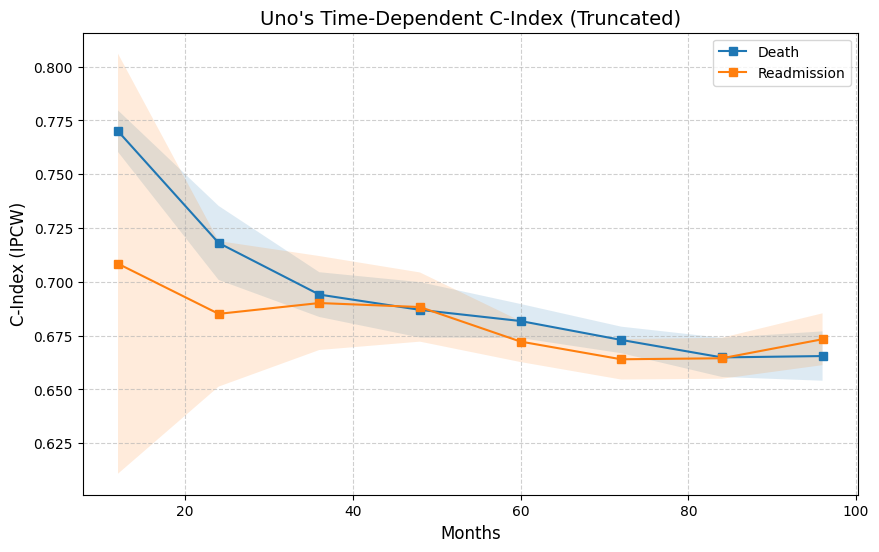


>>> GLOBAL ANTOLINI C-INDEX (Mean +/- Std)
               mean     std
Risk                       
Death        0.6790  0.0103
Readmission  0.6511  0.0115

>>> UNO'S C-INDEX AT KEY TIMES (Mean)
Risk  Death  Readmission
Time                    
12    0.770        0.708
24    0.718        0.685
36    0.694        0.690
48    0.687        0.688
60    0.682        0.672
72    0.673        0.664
84    0.665        0.664
96    0.666        0.673


In [43]:
#@title ⚡ Pooled DeepHit: Uno's C-Index, Antolini & Brier { display-mode: "form" }

# --- 1. INSTALL SK-SURVIVAL (If needed) ---
try:
    from sksurv.util import Surv
    from sksurv.metrics import concordance_index_ipcw
except ImportError:
    !pip install scikit-survival
    from sksurv.util import Surv
    from sksurv.metrics import concordance_index_ipcw

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torchtuples as tt
from pycox.models import DeepHit
from pycox.evaluation import EvalSurv
from pycox.preprocessing.label_transforms import LabTransDiscreteTime
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import lifelines

# --- CONFIGURATION ---
N_IMPUTATIONS = len(imputations_list_jan26)
TIMES_EVAL = [12, 24, 36, 48, 60, 72, 84, 96] # For Brier
TIMES_UNO = [12, 24, 36, 48, 60, 72, 84, 96] # Specific horizons for Uno's C-Index
NUM_DURATIONS = 100
BATCH_SIZE = 512
EPOCHS = 150
LR = 0.01
NUM_RISKS = 3
device = 'cuda' if torch.cuda.is_available() else 'cpu'

# --- HELPER: VECTORIZED BRIER SCORE ---
def compute_brier_competing_vectorized(cif_preds, censoring_kmf, y_time, y_event, target_event, time_horizon):
    n = len(y_time)
    w_horizon = censoring_kmf.predict(time_horizon)
    if w_horizon == 0: w_horizon = 1e-5
    w_obs = censoring_kmf.predict(y_time)
    w_obs[w_obs == 0] = 1e-5

    scores = np.zeros(n)
    mask_after = y_time > time_horizon
    scores[mask_after] = (cif_preds[mask_after]**2) / w_horizon

    mask_before = ~mask_after
    mask_target = mask_before & (y_event == target_event)
    scores[mask_target] = ((1 - cif_preds[mask_target])**2) / w_obs[mask_target]

    mask_competing = mask_before & (y_event != target_event) & (y_event != 0)
    scores[mask_competing] = (cif_preds[mask_competing]**2) / w_obs[mask_competing]

    valid_mask = mask_after | (mask_before & (y_event != 0))
    return scores[valid_mask].mean()

# --- MAIN LOOP ---
pooled_metrics = []

print(f"⚡ Starting Comprehensive Evaluation on {N_IMPUTATIONS} Imputations...")

for imp_idx in range(N_IMPUTATIONS):
    print(f"\n📂 Imputation {imp_idx + 1}/{N_IMPUTATIONS}...", end="")

    # 1. DATA PREP
    X_raw = imputations_list_jan26[imp_idx]
    X_curr = pd.get_dummies(X_raw, drop_first=True).astype('float32')
    y_d = y_surv_death_list[imp_idx]
    y_r = y_surv_readm_list[imp_idx]

    t_base = y_d['time'].values.astype('float32') if hasattr(y_d['time'], 'values') else y_d['time'].astype('float32')
    e_d = y_d['event'].values.astype(bool) if hasattr(y_d['event'], 'values') else y_d['event'].astype(bool)
    e_r = y_r['event'].values.astype(bool) if hasattr(y_r['event'], 'values') else y_r['event'].astype(bool)
    t_r_vals = y_r['time'].values if hasattr(y_r['time'], 'values') else y_r['time']

    events_cr = np.zeros_like(t_base, dtype=int)
    mask_both = e_d & e_r
    events_cr[mask_both & (t_base <= t_r_vals)] = 1
    events_cr[mask_both & (t_r_vals < t_base)] = 2
    events_cr[e_d & (~e_r)] = 1
    events_cr[e_r & (~e_d)] = 2
    times_cr = t_base.copy()

    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=imp_idx)
    train_idx, val_idx = next(skf.split(X_curr, events_cr))

    X_train, X_val = X_curr.iloc[train_idx].values, X_curr.iloc[val_idx].values
    t_train, e_train = times_cr[train_idx], events_cr[train_idx]
    t_val, e_val = times_cr[val_idx], events_cr[val_idx]

    labtrans = LabTransDiscreteTime(NUM_DURATIONS)
    y_train_trans = labtrans.fit_transform(t_train, e_train)
    y_val_trans = labtrans.transform(t_val, e_val)
    y_train_trans = (y_train_trans[0].astype(np.int64), y_train_trans[1].astype(np.int64))
    y_val_trans = (y_val_trans[0].astype(np.int64), y_val_trans[1].astype(np.int64))

    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train)
    X_val = scaler.transform(X_val)

    # Train
    net_base = tt.practical.MLPVanilla(X_train.shape[1], [128, 128], labtrans.out_features * NUM_RISKS,
                                       batch_norm=True, dropout=0.2, activation=nn.ReLU)
    net = nn.Sequential(net_base, nn.Unflatten(1, (NUM_RISKS, -1)))
    model = DeepHit(net, tt.optim.Adam, alpha=0.2, sigma=0.1, duration_index=labtrans.cuts)
    model.set_device(device)
    model.optimizer.set_lr(LR)
    model.fit(X_train, y_train_trans, batch_size=BATCH_SIZE, epochs=EPOCHS, verbose=False,
              val_data=tt.tuplefy(X_val, y_val_trans), callbacks=[tt.callbacks.EarlyStopping()])

    # 2. EVALUATION SETUP
    censoring_kmf = lifelines.KaplanMeierFitter()
    censoring_kmf.fit(t_train, event_observed=(e_train == 0).astype(int))

    cif_val = model.predict_cif(X_val)
    model_times = model.duration_index

    # ** PREPARE SKSURV FORMAT (Structured Arrays) **
    # scikit-survival needs [(True, 12.0), (False, 34.0)...]
    # For Training Data (needed for IPCW estimation):
    # We create a generic "Any Event" structure for IPCW context,
    # but strictly Uno's per-cause needs specific handling.
    # Here we follow the standard: Train structure defines the censoring distribution.
    struc_train = Surv.from_arrays(e_train != 0, t_train)

    risk_map = {1: 'Death', 2: 'Readmission'}

    for r_idx, r_name in risk_map.items():
        # A. Antolini (Global)
        surv_df = pd.DataFrame(1 - cif_val[r_idx, :, :], index=model_times)
        ev = EvalSurv(surv_df, t_val, (e_val == r_idx).astype(int), censor_surv='km')
        pooled_metrics.append({'Imp': imp_idx, 'Risk': r_name, 'Metric': 'Antolini C-Index', 'Time': 'Global', 'Value': ev.concordance_td('antolini')})

        # B. Uno's Truncated C-Index (Specific Times)
        # Prepare Test Structure for THIS SPECIFIC RISK
        # Competing events are treated as censored (Status = False) for cause-specific C-index
        event_binary_val = (e_val == r_idx)
        struc_test = Surv.from_arrays(event_binary_val, t_val)

        for t in TIMES_UNO:
            # Find closest time index in DeepHit grid
            idx_t = np.searchsorted(model_times, t)
            if idx_t >= len(model_times): idx_t = len(model_times) - 1

            # Risk score = Probability of event occurring by time t (CIF)
            risk_scores = cif_val[r_idx, idx_t, :]

            try:
                # Uno's C-Index Calculation
                uno_c, _, _, _, _ = concordance_index_ipcw(struc_train, struc_test, risk_scores, tau=t)
                pooled_metrics.append({'Imp': imp_idx, 'Risk': r_name, 'Metric': "Uno's C-Index", 'Time': t, 'Value': uno_c})
            except Exception as e:
                # Sometimes fails if no events occur before tau in test set
                pass

        # C. Brier Score (Vectorized)
        for t in TIMES_EVAL:
            idx_t = np.searchsorted(model_times, t)
            if idx_t >= len(model_times): idx_t = len(model_times) - 1
            bs = compute_brier_competing_vectorized(cif_val[r_idx, idx_t, :], censoring_kmf, t_val, e_val, r_idx, t)
            pooled_metrics.append({'Imp': imp_idx, 'Risk': r_name, 'Metric': 'Brier Score', 'Time': t, 'Value': bs})

    print(" Done.")

# --- AGGREGATE RESULTS ---
df_res = pd.DataFrame(pooled_metrics)

# 1. Plot Uno's C-Index
plt.figure(figsize=(10, 6))
uno_data = df_res[df_res['Metric'] == "Uno's C-Index"].groupby(['Risk', 'Time'])['Value'].agg(['mean', 'std']).reset_index()

for risk in ['Death', 'Readmission']:
    subset = uno_data[uno_data['Risk'] == risk]
    if not subset.empty:
        plt.plot(subset['Time'], subset['mean'], marker='s', label=f"{risk}")
        plt.fill_between(subset['Time'], subset['mean'] - subset['std'], subset['mean'] + subset['std'], alpha=0.15)

plt.title("Uno's Time-Dependent C-Index (Truncated)", fontsize=14)
plt.xlabel("Months", fontsize=12)
plt.ylabel("C-Index (IPCW)", fontsize=12)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

# 2. Print Summary Tables
print("\n>>> GLOBAL ANTOLINI C-INDEX (Mean +/- Std)")
print(df_res[df_res['Metric'] == 'Antolini C-Index'].groupby('Risk')['Value'].agg(['mean', 'std']).round(4))

print("\n>>> UNO'S C-INDEX AT KEY TIMES (Mean)")
print(uno_data.pivot(index='Time', columns='Risk', values='mean').round(3))

⚡ Starting GRAND POOLED ANALYSIS on 5 Imputations...

📂 Imputation 1/5... Done.

📂 Imputation 2/5... Done.

📂 Imputation 3/5... Done.

📂 Imputation 4/5... Done.

📂 Imputation 5/5... Done.


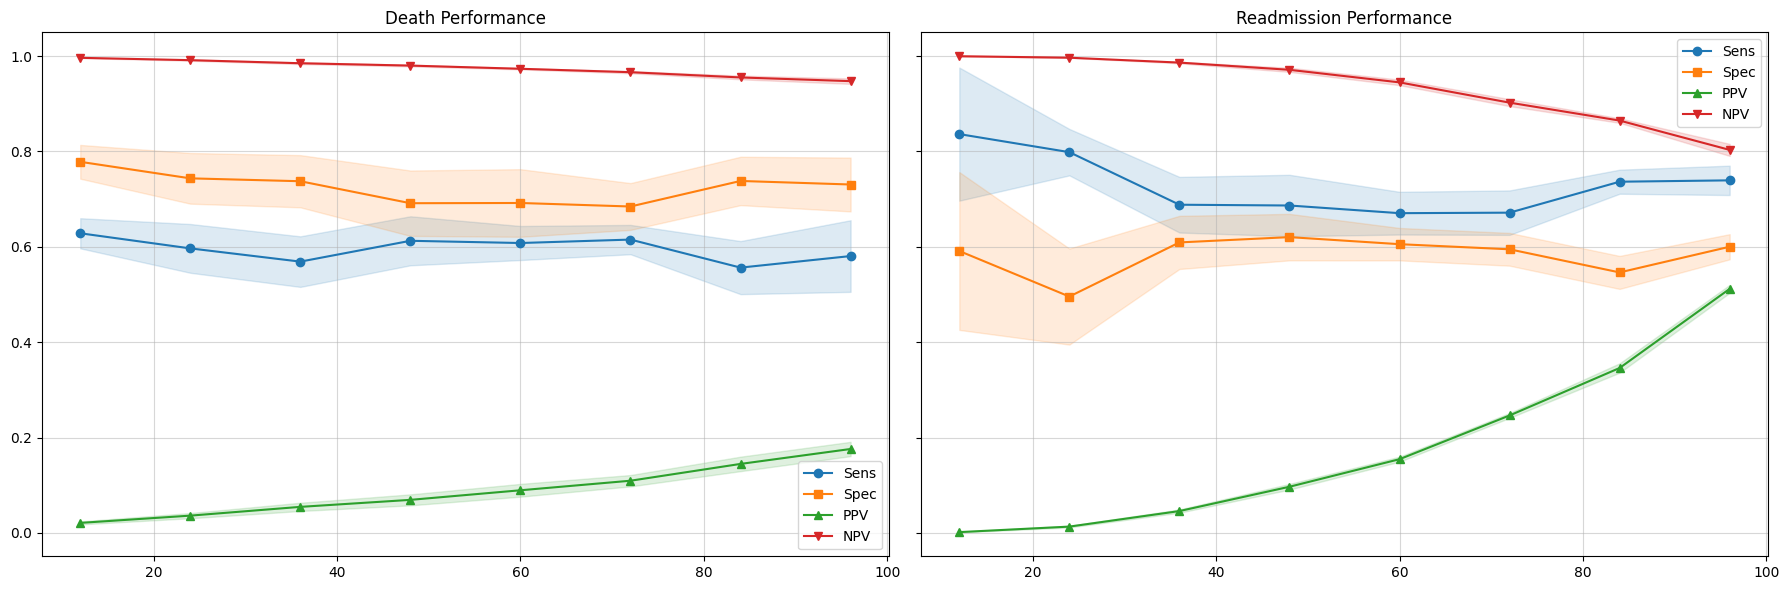

<Figure size 1000x500 with 0 Axes>

In [44]:
#@title ⚡ Comprehensive Pooled Analysis (All Metrics) { display-mode: "form" }

# --- 1. IMPORTS & INSTALLS ---
try:
    from sksurv.util import Surv
    from sksurv.metrics import concordance_index_ipcw
except ImportError:
    !pip install scikit-survival
    from sksurv.util import Surv
    from sksurv.metrics import concordance_index_ipcw

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torchtuples as tt
from pycox.models import DeepHit
from pycox.evaluation import EvalSurv
from pycox.preprocessing.label_transforms import LabTransDiscreteTime
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, roc_curve
import matplotlib.pyplot as plt
import lifelines

# --- CONFIGURATION ---
N_IMPUTATIONS = len(imputations_list_jan26)
TIMES_EVAL = [12, 24, 36, 48, 60, 72, 84, 96]   # For Brier / Sens / Spec
TIMES_UNO = [12, 36, 60, 84]                    # Specific horizons for Uno's C-Index
NUM_DURATIONS = 100
BATCH_SIZE = 512
EPOCHS = 150
LR = 0.01
NUM_RISKS = 3
device = 'cuda' if torch.cuda.is_available() else 'cpu'

# --- HELPER 1: BINARY TARGET EXTRACTION ---
def get_binary_target(events, times, risk_id, horizon):
    """
    Creates binary target for a specific risk at a specific horizon.
    Excludes patients censored before horizon who didn't have the event.
    """
    # 1. Event occurred before or at horizon?
    event_happened = (times <= horizon) & (events == risk_id)

    # 2. Censored before horizon? (Excluding those who had the event)
    # Censored = (Status 0) AND (Time <= Horizon)
    # OR Competing Risk (Status != Risk_ID and Status != 0) AND (Time <= Horizon)
    # NOTE: In pure binary classification for sensitivity, competing risks are often treated
    # as "0" (did not have OUR event), but strictly speaking, standard metrics drop them or weight them.
    # Here we define:
    # 1 = Had Event by Horizon
    # 0 = Survived past Horizon OR Had Competing Event (treated as "Not Our Event")
    # Exclude = Censored (Status 0) before Horizon

    censored_early = (events == 0) & (times < horizon)
    mask = ~censored_early # Keep everyone else

    y_bin = event_happened[mask].astype(int)
    return y_bin, mask

# --- HELPER 2: SENS/SPEC/PPV/NPV ---
def get_metrics_at_threshold(y_true, probas):
    if len(np.unique(y_true)) < 2: return {k: np.nan for k in ['Sens', 'Spec', 'PPV', 'NPV']}
    fpr, tpr, thresholds = roc_curve(y_true, probas)
    idx = np.argmax(tpr - fpr)
    thresh = thresholds[idx]
    y_pred = (probas >= thresh).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0,1]).ravel()
    with np.errstate(divide='ignore', invalid='ignore'):
        return {
            'Sens': tp/(tp+fn) if (tp+fn)>0 else 0,
            'Spec': tn/(tn+fp) if (tn+fp)>0 else 0,
            'PPV': tp/(tp+fp) if (tp+fp)>0 else 0,
            'NPV': tn/(tn+fn) if (tn+fn)>0 else 0
        }

# --- HELPER 3: VECTORIZED BRIER SCORE (GRAF) ---
def compute_brier_competing_vectorized(cif_preds, censoring_kmf, y_time, y_event, target_event, time_horizon):
    """Vectorized IPCW Brier Score for Competing Risks."""
    n = len(y_time)
    w_horizon = censoring_kmf.predict(time_horizon)
    if w_horizon == 0: w_horizon = 1e-5

    w_obs = censoring_kmf.predict(y_time)
    w_obs[w_obs == 0] = 1e-5

    scores = np.zeros(n)

    # Case 1: T > Horizon (Censored later or Event later) -> Truth=0
    mask_after = y_time > time_horizon
    scores[mask_after] = (cif_preds[mask_after]**2) / w_horizon

    mask_before = ~mask_after

    # Case 2: T <= Horizon AND Event == Target -> Truth=1
    mask_target = mask_before & (y_event == target_event)
    scores[mask_target] = ((1 - cif_preds[mask_target])**2) / w_obs[mask_target]

    # Case 3: T <= Horizon AND Event == Competing -> Truth=0
    mask_competing = mask_before & (y_event != target_event) & (y_event != 0)
    scores[mask_competing] = (cif_preds[mask_competing]**2) / w_obs[mask_competing]

    # Exclude early censoring (y_event=0 & y_time <= horizon) from mean
    valid_mask = mask_after | (mask_before & (y_event != 0))

    if valid_mask.sum() == 0: return np.nan
    return scores[valid_mask].mean()

# --- MODEL CLASS ---
class CauseSpecificNet(nn.Module):
    def __init__(self, net, num_risks):
        super().__init__()
        self.net = net
        self.num_risks = num_risks
    def forward(self, x):
        out = self.net(x)
        return out.view(out.size(0), self.num_risks, -1)

# --- MAIN LOOP ---
pooled_results = []
print(f"⚡ Starting GRAND POOLED ANALYSIS on {N_IMPUTATIONS} Imputations...")

for imp_idx in range(N_IMPUTATIONS):
    print(f"\n📂 Imputation {imp_idx + 1}/{N_IMPUTATIONS}...", end="")

    # 1. LOAD & PREP
    X_raw = imputations_list_jan26[imp_idx]
    X_curr = pd.get_dummies(X_raw, drop_first=True).astype('float32')
    y_d = y_surv_death_list[imp_idx]
    y_r = y_surv_readm_list[imp_idx]

    t_base = y_d['time'].values.astype('float32') if hasattr(y_d['time'], 'values') else y_d['time'].astype('float32')
    e_d = y_d['event'].values.astype(bool) if hasattr(y_d['event'], 'values') else y_d['event'].astype(bool)
    e_r = y_r['event'].values.astype(bool) if hasattr(y_r['event'], 'values') else y_r['event'].astype(bool)
    t_r_vals = y_r['time'].values if hasattr(y_r['time'], 'values') else y_r['time']

    # Competing Risks Setup
    events_cr = np.zeros_like(t_base, dtype=int)
    mask_both = e_d & e_r
    events_cr[mask_both & (t_base <= t_r_vals)] = 1
    events_cr[mask_both & (t_r_vals < t_base)] = 2
    events_cr[e_d & (~e_r)] = 1
    events_cr[e_r & (~e_d)] = 2
    times_cr = t_base.copy()

    # Split
    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=imp_idx)
    train_idx, val_idx = next(skf.split(X_curr, events_cr))
    X_train, X_val = X_curr.iloc[train_idx].values, X_curr.iloc[val_idx].values
    t_train, e_train = times_cr[train_idx], events_cr[train_idx]
    t_val, e_val = times_cr[val_idx], events_cr[val_idx]

    # Preproc
    labtrans = LabTransDiscreteTime(NUM_DURATIONS)
    y_train_trans = labtrans.fit_transform(t_train, e_train)
    y_val_trans = labtrans.transform(t_val, e_val)
    y_train_trans = (y_train_trans[0].astype(np.int64), y_train_trans[1].astype(np.int64))
    y_val_trans = (y_val_trans[0].astype(np.int64), y_val_trans[1].astype(np.int64))

    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train)
    X_val = scaler.transform(X_val)

    # Train
    net_base = tt.practical.MLPVanilla(X_train.shape[1], [128, 128], labtrans.out_features * NUM_RISKS,
                                       batch_norm=True, dropout=0.2, activation=nn.ReLU)
    net = CauseSpecificNet(net_base, NUM_RISKS)
    model = DeepHit(net, tt.optim.Adam, alpha=0.2, sigma=0.1, duration_index=labtrans.cuts)
    model.set_device(device)
    model.optimizer.set_lr(LR)
    model.fit(X_train, y_train_trans, batch_size=BATCH_SIZE, epochs=EPOCHS, verbose=False,
              val_data=tt.tuplefy(X_val, y_val_trans), callbacks=[tt.callbacks.EarlyStopping()])

    # --- EVALUATION ---
    censoring_kmf = lifelines.KaplanMeierFitter()
    censoring_kmf.fit(t_train, event_observed=(e_train == 0).astype(int))

    cif_val = model.predict_cif(X_val)
    model_times = model.duration_index

    # Prepare sksurv training structure (for Uno's IPCW)
    struc_train = Surv.from_arrays(e_train != 0, t_train)

    risk_map = {1: 'Death', 2: 'Readmission'}

    for r_idx, r_name in risk_map.items():
        # 1. Antolini (Global)
        surv_df = pd.DataFrame(1 - cif_val[r_idx, :, :], index=model_times)
        ev = EvalSurv(surv_df, t_val, (e_val == r_idx).astype(int), censor_surv='km')
        c_ant = ev.concordance_td('antolini')
        pooled_results.append({'Imp': imp_idx, 'Risk': r_name, 'Metric': 'Antolini C-Index', 'Time': 999, 'Value': c_ant})

        # 2. Uno's C-Index (Specific Times)
        struc_test = Surv.from_arrays(e_val == r_idx, t_val)
        for t in TIMES_UNO:
            idx_t = np.searchsorted(model_times, t)
            if idx_t >= len(model_times): idx_t = len(model_times) - 1
            risk_scores = cif_val[r_idx, idx_t, :]
            try:
                uno_c, _, _, _, _ = concordance_index_ipcw(struc_train, struc_test, risk_scores, tau=t)
                pooled_results.append({'Imp': imp_idx, 'Risk': r_name, 'Metric': "Uno's C-Index", 'Time': t, 'Value': uno_c})
            except: pass

        # 3. Brier Score & Sens/Spec Loop
        for t in TIMES_EVAL:
            idx_t = np.searchsorted(model_times, t)
            if idx_t >= len(model_times): idx_t = len(model_times) - 1
            pred_at_t = cif_val[r_idx, idx_t, :]

            # Brier
            bs = compute_brier_competing_vectorized(pred_at_t, censoring_kmf, t_val, e_val, r_idx, t)
            pooled_results.append({'Imp': imp_idx, 'Risk': r_name, 'Metric': 'Brier Score', 'Time': t, 'Value': bs})

            # Sens/Spec/PPV/NPV
            y_bin, mask = get_binary_target(e_val, t_val, r_idx, t)
            m_metrics = get_metrics_at_threshold(y_bin, pred_at_t[mask])
            for k, v in m_metrics.items():
                pooled_results.append({'Imp': imp_idx, 'Risk': r_name, 'Metric': k, 'Time': t, 'Value': v})

    print(" Done.")

# --- REPORTING ---
df_res = pd.DataFrame(pooled_results)
df_agg = df_res.groupby(['Risk', 'Metric', 'Time'])['Value'].agg(['mean', 'std', 'count']).reset_index()
df_agg['se'] = df_agg['std'].fillna(0) / np.sqrt(df_agg['count'])
df_agg['lower'] = df_agg['mean'] - 1.96 * df_agg['se']
df_agg['upper'] = df_agg['mean'] + 1.96 * df_agg['se']

# 1. VISUALIZE SENS/SPEC/NPV/PPV
fig, axes = plt.subplots(1, 2, figsize=(18, 6), sharey=True)
colors = {'Sens': '#1f77b4', 'Spec': '#ff7f0e', 'PPV': '#2ca02c', 'NPV': '#d62728'}
markers = {'Sens': 'o', 'Spec': 's', 'PPV': '^', 'NPV': 'v'}

for i, risk in enumerate(['Death', 'Readmission']):
    ax = axes[i]
    subset = df_agg[(df_agg['Risk'] == risk) & (df_agg['Time'] <= 96) & (df_agg['Metric'].isin(colors.keys()))]
    for m in colors.keys():
        d = subset[subset['Metric'] == m]
        ax.plot(d['Time'], d['mean'], label=m, color=colors[m], marker=markers[m])
        ax.fill_between(d['Time'], d['lower'], d['upper'], color=colors[m], alpha=0.15)
    ax.set_title(f"{risk} Performance")
    ax.legend()
    ax.grid(True, alpha=0.5)

plt.tight_layout()
plt.show()


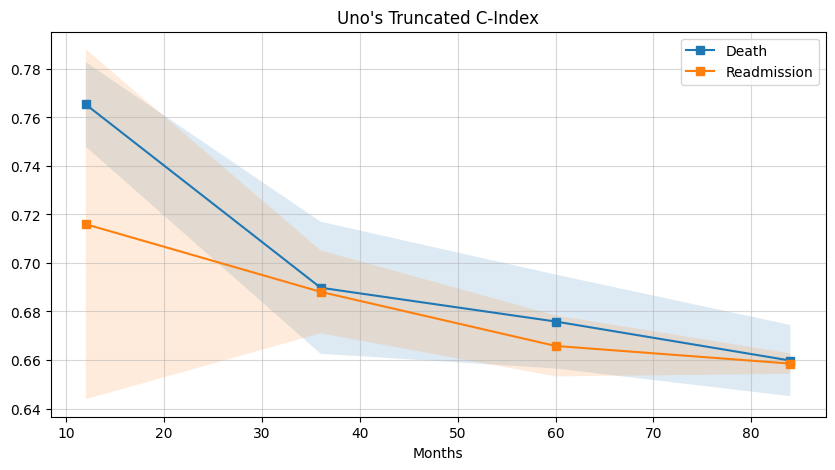


>>> BRIER SCORES (Mean)
Risk   Death  Readmission
Time                     
12    0.0076       0.0007
24    0.0165       0.0092
36    0.0282       0.0315
48    0.0407       0.0717
60    0.0560       0.1351
72    0.0746       0.2536
84    0.0976       0.4172
96    0.1236       0.6949

>>> GLOBAL ANTOLINI C-INDEX
           Risk   mean  lower  upper
0         Death  0.671   0.65  0.692
45  Readmission  0.646   0.64  0.653


In [45]:
# 2. VISUALIZE UNO'S C-INDEX
plt.figure(figsize=(10, 5))
uno_df = df_agg[df_agg['Metric'] == "Uno's C-Index"]
for risk in ['Death', 'Readmission']:
    d = uno_df[uno_df['Risk'] == risk]
    plt.plot(d['Time'], d['mean'], marker='s', label=risk)
    plt.fill_between(d['Time'], d['lower'], d['upper'], alpha=0.15)
plt.title("Uno's Truncated C-Index")
plt.xlabel("Months")
plt.legend()
plt.grid(True, alpha=0.5)
plt.show()

# 3. PRINT BRIER SCORES
print("\n>>> BRIER SCORES (Mean)")
print(df_agg[df_agg['Metric'] == 'Brier Score'].pivot(index='Time', columns='Risk', values='mean').round(4))

# 4. PRINT GLOBAL ANTOLINI
print("\n>>> GLOBAL ANTOLINI C-INDEX")
print(df_agg[df_agg['Metric'] == 'Antolini C-Index'][['Risk', 'mean', 'lower', 'upper']].round(3))

### SHAP

⚡ Generating SHAP Values for Month 12...
   (Background samples: 100, Test samples: 100)
   Summarizing background data with K-Means...
   Computing SHAP values for 100 validation samples...


  0%|          | 0/100 [00:00<?, ?it/s]

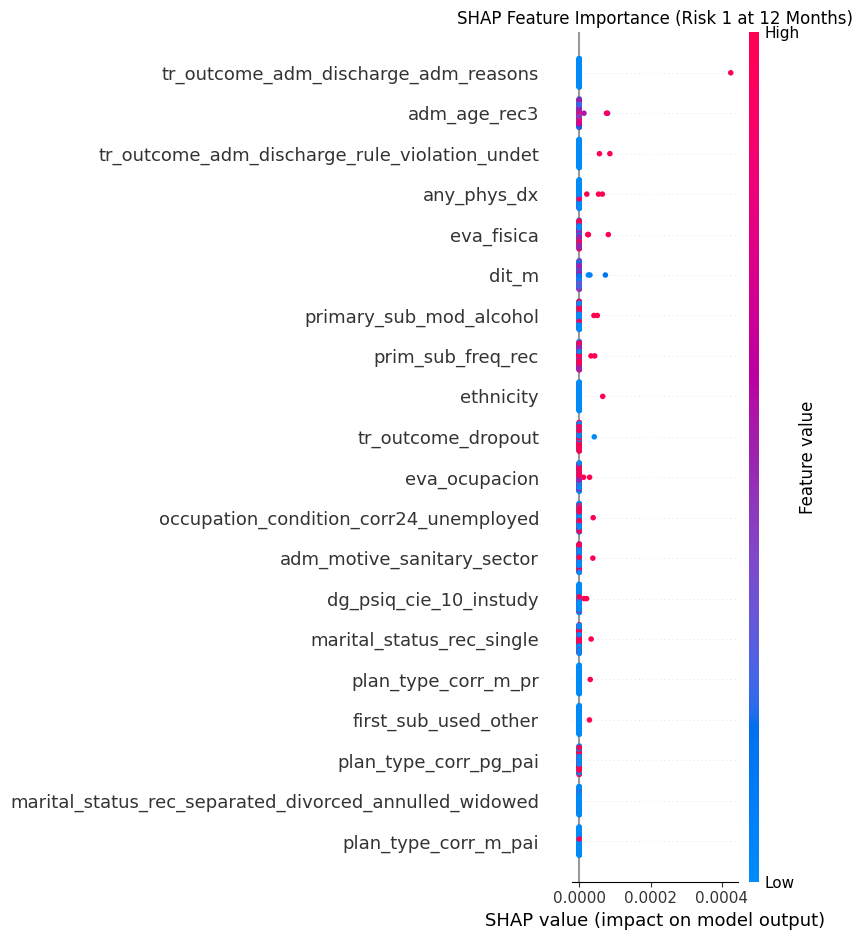

✅ SHAP analysis complete.


In [34]:
#@title ⚡ Fix & Resume SHAP Analysis { display-mode: "form" }

import shap
import numpy as np
import torch
import matplotlib.pyplot as plt

# --- 1. FORM PARAMETERS ---
target_month = 12 #@param {type:"integer"}
background_sample_size = 100 #@param {type:"slider", min:10, max:200, step:10}
test_sample_size = 100 #@param {type:"slider", min:10, max:100, step:10}
risk_index = 1 #@param {type:"integer"}
# Note: risk_index = 1 implies the second risk (e.g., Death) in a competing risk scenario. Use 0 for single risk.

# --- 2. ROBUST PREDICTION WRAPPER ---
def model_predict_wrapper(x_numpy):
    """
    Wrapper to convert Numpy input (from SHAP) -> Tensor -> Model -> Risk Score -> Numpy
    """
    # Convert Input (Numpy -> Tensor on GPU)
    # Handle case where x_numpy might be a single instance or batch
    if x_numpy.ndim == 1:
        x_numpy = x_numpy.reshape(1, -1)

    x_tensor = torch.from_numpy(x_numpy).float().to(device)

    # Get Predictions
    with torch.no_grad():
        # Assumes model.predict_cif returns (Risks, Time, Batch) or similar
        # If your model returns (Batch, Time, Risks), adjust indexing below
        out = model.predict_cif(x_tensor)

    # Find the index in duration_index closest to target_month
    idx_t = np.searchsorted(model.duration_index, target_month)
    if idx_t >= len(model.duration_index):
        idx_t = len(model.duration_index) - 1

    # Extract Specific Risk and Time
    # Expected shape check logic could go here
    try:
        # Assuming shape: [Risks, Time, Batch] based on your previous code
        # We take the slice for the specific risk and time point
        risk_score = out[risk_index, idx_t, :]
    except IndexError:
        # Fallback for single risk models where shape might be [Time, Batch] or [Batch, Time]
        # Adjust this depending on your specific model architecture (e.g., DeepSurv vs DeepHit)
        risk_score = out[idx_t, :]

    return risk_score.cpu().numpy()

# --- 3. RESUME SHAP ---
print(f"⚡ Generating SHAP Values for Month {target_month}...")
print(f"   (Background samples: {background_sample_size}, Test samples: {test_sample_size})")

try:
    # --- ROBUSTNESS FIX: K-Means Summary ---
    # Instead of random rows, use K-Means to summarize the background distribution.
    # This creates a more stable baseline and reduces variance in SHAP values.
    print("   Summarizing background data with K-Means...")
    background_summary = shap.kmeans(X_train, background_sample_size)

    # Initialize Explainer
    explainer = shap.KernelExplainer(model_predict_wrapper, background_summary)

    # Calculate SHAP values for validation subset
    print(f"   Computing SHAP values for {test_sample_size} validation samples...")
    X_val_sample = X_val[:test_sample_size]

    # nsamples='auto' allows SHAP to choose enough evaluations to converge
    shap_values = explainer.shap_values(X_val_sample, nsamples='auto', silent=False)

    # Feature Names
    if hasattr(X_curr, 'columns'):
        feature_names = X_curr.columns.tolist()
    else:
        feature_names = [f"Feature {i}" for i in range(X_val.shape[1])]

    # --- PLOTTING ---
    plt.figure(figsize=(10, 6))
    plt.title(f"SHAP Feature Importance (Risk {risk_index} at {target_month} Months)")

    # Summary Plot (Beeswarm)
    shap.summary_plot(shap_values, X_val_sample, feature_names=feature_names)

    # Optional: Bar plot for absolute importance
    # plt.figure(figsize=(10, 6))
    # shap.summary_plot(shap_values, X_val_sample, feature_names=feature_names, plot_type="bar")

    print("✅ SHAP analysis complete.")

except Exception as e:
    print(f"\n❌ Error during SHAP analysis: {e}")
    print("Tip: Check if 'risk_index' matches the dimensions of your model output.")

⚡ Generating SHAP Values for Month 12...
   (Background samples: 100, Test samples: 100)
   Summarizing background data with K-Means...
   Computing SHAP values for 100 validation samples...


  0%|          | 0/100 [00:00<?, ?it/s]

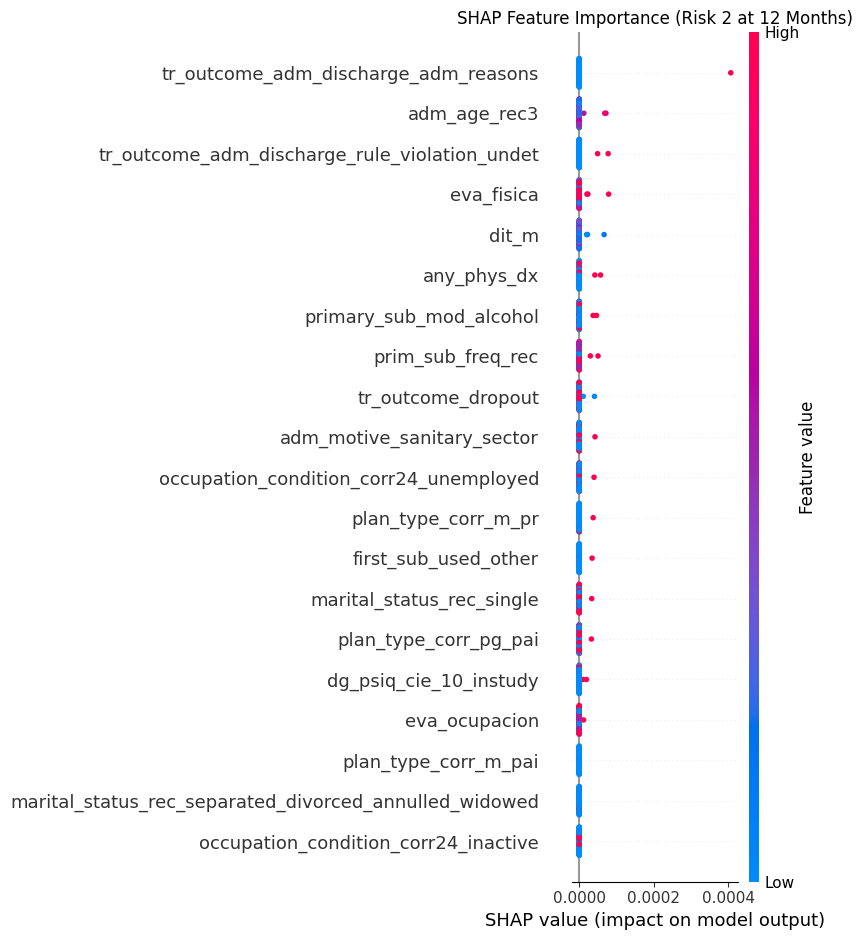

✅ SHAP analysis complete.


In [33]:
#@title ⚡ Fix & Resume SHAP Analysis (2: Readmission) { display-mode: "form" }

import shap
import numpy as np
import torch
import matplotlib.pyplot as plt

# --- 1. FORM PARAMETERS ---
target_month = 12 #@param {type:"integer"}
background_sample_size = 100 #@param {type:"slider", min:10, max:200, step:10}
test_sample_size = 100 #@param {type:"slider", min:10, max:100, step:10}
risk_index = 2 #@param {type:"integer"}
# Note: risk_index = 1 implies the second risk (e.g., Death) in a competing risk scenario. Use 0 for single risk.

# --- 2. ROBUST PREDICTION WRAPPER ---
def model_predict_wrapper(x_numpy):
    """
    Wrapper to convert Numpy input (from SHAP) -> Tensor -> Model -> Risk Score -> Numpy
    """
    # Convert Input (Numpy -> Tensor on GPU)
    # Handle case where x_numpy might be a single instance or batch
    if x_numpy.ndim == 1:
        x_numpy = x_numpy.reshape(1, -1)

    x_tensor = torch.from_numpy(x_numpy).float().to(device)

    # Get Predictions
    with torch.no_grad():
        # Assumes model.predict_cif returns (Risks, Time, Batch) or similar
        # If your model returns (Batch, Time, Risks), adjust indexing below
        out = model.predict_cif(x_tensor)

    # Find the index in duration_index closest to target_month
    idx_t = np.searchsorted(model.duration_index, target_month)
    if idx_t >= len(model.duration_index):
        idx_t = len(model.duration_index) - 1

    # Extract Specific Risk and Time
    # Expected shape check logic could go here
    try:
        # Assuming shape: [Risks, Time, Batch] based on your previous code
        # We take the slice for the specific risk and time point
        risk_score = out[risk_index, idx_t, :]
    except IndexError:
        # Fallback for single risk models where shape might be [Time, Batch] or [Batch, Time]
        # Adjust this depending on your specific model architecture (e.g., DeepSurv vs DeepHit)
        risk_score = out[idx_t, :]

    return risk_score.cpu().numpy()

# --- 3. RESUME SHAP ---
print(f"⚡ Generating SHAP Values for Month {target_month}...")
print(f"   (Background samples: {background_sample_size}, Test samples: {test_sample_size})")

try:
    # --- ROBUSTNESS FIX: K-Means Summary ---
    # Instead of random rows, use K-Means to summarize the background distribution.
    # This creates a more stable baseline and reduces variance in SHAP values.
    print("   Summarizing background data with K-Means...")
    background_summary = shap.kmeans(X_train, background_sample_size)

    # Initialize Explainer
    explainer = shap.KernelExplainer(model_predict_wrapper, background_summary)

    # Calculate SHAP values for validation subset
    print(f"   Computing SHAP values for {test_sample_size} validation samples...")
    X_val_sample = X_val[:test_sample_size]

    # nsamples='auto' allows SHAP to choose enough evaluations to converge
    shap_values = explainer.shap_values(X_val_sample, nsamples='auto', silent=False)

    # Feature Names
    if hasattr(X_curr, 'columns'):
        feature_names = X_curr.columns.tolist()
    else:
        feature_names = [f"Feature {i}" for i in range(X_val.shape[1])]

    # --- PLOTTING ---
    plt.figure(figsize=(10, 6))
    plt.title(f"SHAP Feature Importance (Risk {risk_index} at {target_month} Months)")

    # Summary Plot (Beeswarm)
    shap.summary_plot(shap_values, X_val_sample, feature_names=feature_names)

    # Optional: Bar plot for absolute importance
    # plt.figure(figsize=(10, 6))
    # shap.summary_plot(shap_values, X_val_sample, feature_names=feature_names, plot_type="bar")

    print("✅ SHAP analysis complete.")

except Exception as e:
    print(f"\n❌ Error during SHAP analysis: {e}")
    print("Tip: Check if 'risk_index' matches the dimensions of your model output.")